# Image generation with Variational Autoencoders (VAE)

Variational autoencoders (VAE) are powerful models for data generation. Even though their outputs are often not as good as those of GANs and diffusion models, they have the big advantage of being relatively easy to both implement and train.  

An excellent reading to better understand VAEs is the ["Tutorial on Variational Autoencoders"](https://arxiv.org/abs/1606.05908) by Carl Doersch.

Like plains autoencoders, VAEs are made of two main components: an encoder $E$ and a decoder $D$.

Unlike plain autoencoders, the encoder does not simply output a vector of latent features $z$ the input $x$, but it outputs a distribution $p(z|x)$ from which $z$ is drawn. In practice such a distribution is supposed to be Gaussian, and the encoder outputs its mean $\mu(x)$ and the covariance matrix $\Sigma(x)$.

The decoder computes the output $y$ from the latent variables $z$. At test time we won't have any input, and we will generate new data by applying the decoder to latent features $z$ drawn from a standard Gaussian distribution with zero mean and unitary variance.

Summarizing, during training the process it is:

$x \xrightarrow E \mu, \Sigma \xrightarrow{\text{sample}} z \xrightarrow{D} y$,

and during generation is:

$0, I \xrightarrow{\text{sample}} z \xrightarrow{D} y$,

where $0, I$ are the mean and the covariance of the standard Gaussian distribution.

This pipeline implements a Variational Autoencoder (VAE) to synthesize and manipulate images of faces.

## Setup and Data

It is implemented using PyTorch. For training a subset of the [CelebA dataset](https://mmlab.ie.cuhk.edu.hk/projects/CelebA.html) is used.

Images have been reduced to $96 \times 128$ pixels, and divided in training and validation (which are excluded from this notebook). Each folder is divided in subfolders representing attributes of the faces. These attributes will be utilized in the final section of the pipeline to evaluate latent space attribute manipulation.

In [1]:
import torch
import torch.nn.functional as F
import torchvision
import matplotlib.pyplot as plt

URL = "https://drive.google.com/file/d/1FwhGGIKWUGFR5Q5BtNBFh25LySDuzRpZ/view?usp=sharing"
!gdown --fuzzy -O- "$URL" | tar xf - && echo OK

Downloading...
From: https://drive.google.com/uc?id=1FwhGGIKWUGFR5Q5BtNBFh25LySDuzRpZ
To: <_io.BufferedWriter name='<stdout>'>
100% 11.3M/11.3M [00:00<00:00, 36.9MB/s]
OK


Two objects are set up:
- a `Dataset` representing the set of data we will use for training; for this, we will use the `torchvision.datasets.ImageFolder` class;
- a `DataLoader` that collect random batches of images from the dataset.

2760 training samples
torch.Size([3, 64, 48]) torch.float32


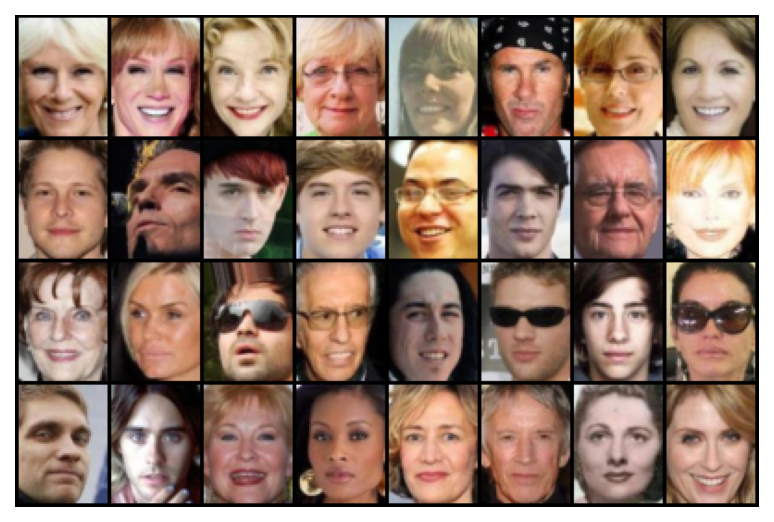

In [2]:
HEIGHT = 64
WIDTH = 48

transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((HEIGHT, WIDTH)),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5) # normalise in [-1,1]
])

train_set = torchvision.datasets.ImageFolder("celebasmall/train", transform=transform) # dataset works like a list
loader = torch.utils.data.DataLoader(train_set, batch_size=32, shuffle=True, drop_last=True, num_workers=2) # last batch (if < 32) is dropped

print(len(train_set), "training samples")
print(train_set[0][0].shape, train_set[0][0].dtype)

def show_faces(faces):
    plt.figure(dpi=150)
    g = torchvision.utils.make_grid(faces, normalize=True, value_range=(-1, 1))
    plt.imshow(g.detach().cpu().permute(1, 2, 0))
    plt.axis("off")
    plt.show()

batch = next(iter(loader))[0]
show_faces(batch)

## Models

The autoencoder includes two main modules:
1. the Encoder;
2. the Decoder.

They will be symmetrical convolution networks.

Given $x$, the Encoder outputs the parameters of a Gaussian distribution:
- the mean $\mu(x)$;
- the logarithm of the elements of a diagonal covariance matrix $\log \sigma^2(x)$.

Computing the logarithm simplifies a little the computation of the loss and removes the need to ensure non-negative variances.  

In [ ]:
from torch.nn.modules.activation import LeakyReLU

class Encoder(torch.nn.Module):
    def __init__(self, height, width, latent_features, features):
        super().__init__()
        self.convs = torch.nn.Sequential(
            torch.nn.Conv2d(3, features//16, 3, 2, 1), # , , kernel, stride, padding
            torch.nn.BatchNorm2d(features//16),
            torch.nn.LeakyReLU(), # better for generative methods
            torch.nn.Conv2d(features//16, features//8, 3, 2, 1),
            torch.nn.BatchNorm2d(features//8),
            torch.nn.LeakyReLU(),
            torch.nn.Conv2d(features//8, features//4, 3, 2, 1),
            torch.nn.BatchNorm2d(features//4),
            torch.nn.LeakyReLU(),
            torch.nn.Conv2d(features//4, features//2, 3, 2, 1),
            torch.nn.BatchNorm2d(features//2),
            torch.nn.LeakyReLU(),
            torch.nn.Conv2d(features//2, features, 3, 1, 1),  # Stride 1 here
            torch.nn.BatchNorm2d(features),
            torch.nn.LeakyReLU(),
        )
        n = (height // 16) * (width // 16)
        self.fc_mu = torch.nn.Linear(features * n, latent_features)
        self.fc_var = torch.nn.Linear(features * n, latent_features)

    def forward(self, x):
        x = self.convs(x)
        x = x.flatten(1)
        mu = self.fc_mu(x)
        log_var =self.fc_var(x)
        return mu, log_var

FEATURES = 128  # 1024
LATENT = 64
encoder = Encoder(HEIGHT, WIDTH, LATENT, FEATURES)
x = torch.zeros(1, 3, HEIGHT, WIDTH)
mu, log_var = encoder(x)
print(mu.size(), log_var.size())
npars = sum(p.numel() for p in encoder.parameters())
print(npars, "parameters")

torch.Size([1, 64]) torch.Size([1, 64])
295616 parameters


In [4]:
class Decoder(torch.nn.Module):
    def __init__(self, height, width, latent_features, features):
        super().__init__()
        self.height = height // 16
        self.width = width // 16
        n = self.height * self.width
        self.fc_input = torch.nn.Linear(latent_features, n * features)
        self.convs = torch.nn.Sequential(
            torch.nn.ConvTranspose2d(features, features//2 ,3, 1, 1, output_padding=0),
            torch.nn.BatchNorm2d(features //2),
            torch.nn.LeakyReLU(),

            torch.nn.ConvTranspose2d(features//2, features// 4,3, 2, 1, output_padding=1),
            torch.nn.BatchNorm2d(features // 4),
            torch.nn.LeakyReLU(),

            torch.nn.ConvTranspose2d(features//4, features//8, 3, 2, 1, output_padding=1),
            torch.nn.BatchNorm2d(features//8),
            torch.nn.LeakyReLU(),

            torch.nn.ConvTranspose2d(features//8, features//16, 3, 2, 1, output_padding=1),
            torch.nn.BatchNorm2d(features // 16),
            torch.nn.LeakyReLU(),

            torch.nn.ConvTranspose2d(features//16, features//16, 3, 2, 1, output_padding=1),
            torch.nn.BatchNorm2d(features //16),
            torch.nn.LeakyReLU(),

            torch.nn.ConvTranspose2d(features//16, 3, 3, 1, 1, output_padding=0),
            torch.nn.Tanh()
        )

    def forward(self, z):
        x = self.fc_input(z)
        x = x.view(x.shape[0], -1, self.height, self.width)
        x = self.convs(x)
        return x


decoder = Decoder(HEIGHT, WIDTH, LATENT, FEATURES)
x = torch.zeros(1, LATENT)
y = decoder(x)
print(y.size())
npars = sum(p.numel() for p in decoder.parameters())
print(npars, "parameters")

torch.Size([1, 3, 64, 48])
198939 parameters


## Training

The loss function for the VAE model is the Evidence Lower BOund.

$\text{ELBO} = E_q[\log q(z|x) - \log p(z)] - E_q[\log p(x|z)]$

The first term is the KL divergence between $q(z|x)$ and $p(z)$.
When the two distributions are Gaussian it is (see https://en.wikipedia.org/wiki/Kullback%E2%80%93Leibler_divergence#Examples):

$E_q[\log q(z|x) - \log p(z)] = D_{KL}(q\|p) = \frac{1}{2}(\text{trace}(\Sigma) + \| \mu \|^2 - \log \det \Sigma)$

The second term is the expected reconstruction error.  When $p(x|z)$ is Gaussian:

$-E_q[\log p(x|z)] = E_q[\frac{1}{2\sigma^2} \| x - \text{decoder}(z) \|^2] + \text{some constant}$

The KL divergence acts as a regularizer, ensuring that the distribution of latent variables is close to the Gaussian distribution of the prior.
The reconstruction error measures how well the input data has been reconstructed. The two terms are linearly combined. The $\frac{1}{\sigma^2}$ coefficients modulates the two terms. Note that VAE may work well even with different kind of errors, like the Mean Absolute Error (MAE).

Considering that we assume $\Sigma = \text{diag}(\sigma^2)$, we can use the following:

$$\text{ELBO} = \| x - \text{decoder}(z) \|_1 + \lambda \left( \sum_j \sigma_j^2(x) + \sum_j \mu_j^2(x) - \sum_j \log \sigma_j^2(x) \right), $$

where $\lambda$ is a parameter balancing the contribution of the two terms.

In [5]:
def elbo_loss(target, generated, mu, log_var, lambda_=1e-4):
    rec_error = (generated - target).abs().mean()
    kl_div = torch.exp(log_var).sum() + mu.pow(2).sum() - log_var.sum()
    loss = rec_error + lambda_ * kl_div
    return loss

def save_model(filename):
    data = {
        "encoder": encoder.state_dict(),
        "decoder": decoder.state_dict(),
        "optimizer": optimizer.state_dict()
    }
    torch.save(data, filename)

def load_model(filename):
    data = torch.load(filename)
    encoder.load_state_dict(data["encoder"])
    decoder.load_state_dict(data["decoder"])
    optimizer.load_state_dict(data["optimizer"])

In [6]:
device = ("cuda" if torch.cuda.is_available() else "cpu")
encoder.to(device)
decoder.to(device)
print(device)

cuda


In [7]:
LR = 1e-3
EPOCHS = 100

params = list(encoder.parameters()) + list(decoder.parameters())
optimizer = torch.optim.Adam(params, LR)

In [ ]:
LAMBDA = 1e-4

totloss = 0.0
steps = 0
for epoch in range(EPOCHS):
    for x, _ in loader:
        x = x.to(device)
        optimizer.zero_grad()

        mu, log_var = encoder(x)
        z = torch.randn_like(mu) * torch.exp(0.5 * log_var) + mu
        xprime = decoder(z)
        loss = elbo_loss(x, xprime, mu, log_var, LAMBDA)

        loss.backward()
        optimizer.step()
        totloss += loss.item()
        steps += 1
        if steps % 100 == 0:
            print(f"[{epoch}] {steps}   {totloss / 100:.3f}")
            totloss = 0
            save_model("vae.pt")
save_model("vae.pt")

## Generation

To generate new data, sample a new batch of latent variables from a standard Gaussian. Then, feed them into the decoder.

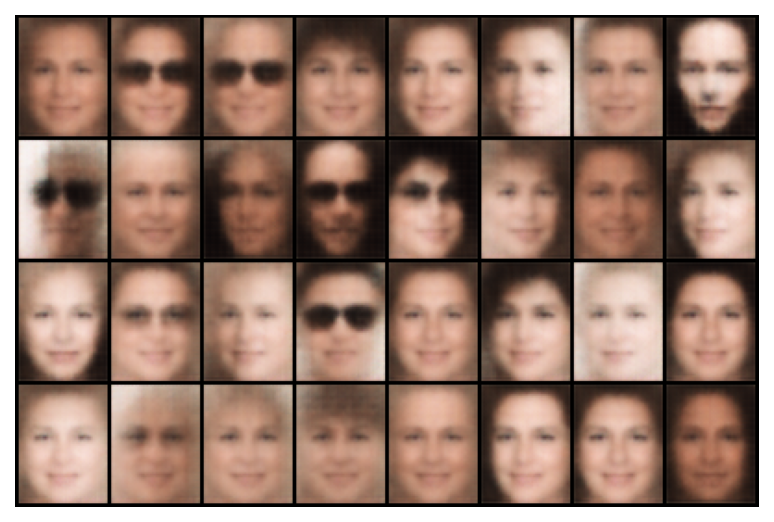

In [9]:
# load_model("vae.pt")
z = torch.randn(32, LATENT, device=device)
with torch.no_grad():
  faces = decoder(z)
show_faces(faces)

## Interpolation

When the latent space is good, you can take two latent vectors, interpolate them, and obtain a smooth transition between the two faces.

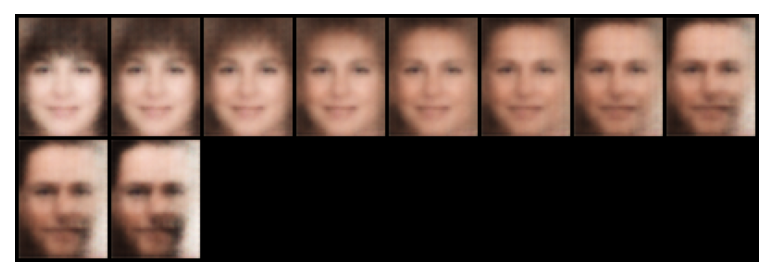

In [12]:
x0 = train_set[200][0][None].to(device)
x1 = train_set[1500][0][None].to(device)

z0, _ = encoder(x0)
z1, _ = encoder(x1)
beta = torch.linspace(0,1,10).to(device).view(10,1) # Changed 0 to 10 for interpolation steps
z = (1-beta) *z0 + beta * z1

with torch.no_grad():
  y = decoder(z)
show_faces(y)